In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
eb = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_168_latest' / 'energy_balance.csv', header=list(range(5)), index_col=[0,1,2]
)
eb.columns = eb.columns.get_level_values(-1).astype(int)
prices = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_168_latest' / 'prices.csv', header=list(range(5)), index_col=[0]
)
prices.columns = prices.columns.get_level_values(-1).astype(int)

In [4]:
eb.head()

wiggle                                                  0             125   \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           3.475197e+08  3.335521e+08   
          Offshore Wind (DC)       AC           4.089725e+08  4.273542e+08   
          Offshore Wind (Floating) AC           5.378150e+02  8.347689e+02   
          Onshore Wind             AC           1.359762e+09  1.306435e+09   
          Run of River             AC           1.608656e+08  1.608795e+08   

wiggle                                                  250           375   \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           3.562204e+08  3.384544e+08   
          Offshore Wind (DC)       AC           4.041752e+08  3.831696e+08   
          Offshore Wind (Floating) AC           4.356694e+02  6.069478e+02   
          Onshore Wind             AC           1.240086e+09  1.204114e+09   
          Run of River             AC           1.608512e+08  1.609690e+08   

wiggle                                                  500           625   \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           3.423551e+08  3.391167e+08   
          Offshore Wind (DC)       AC           3.791198e+08  3.552613e+08   
          Offshore Wind (Floating) AC           3.881054e+02  3.191103e+02   
          Onshore Wind             AC           1.204821e+09  1.209994e+09   
          Run of River             AC           1.609059e+08  1.608809e+08   

wiggle                                                  750           875   \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           3.145530e+08  2.771877e+08   
          Offshore Wind (DC)       AC           3.485392e+08  3.107369e+08   
          Offshore Wind (Floating) AC           5.665085e+02  7.016484e+02   
          Onshore Wind             AC           1.184210e+09  1.202823e+09   
          Run of River             AC           1.611393e+08  1.611763e+08   

wiggle                                                  1000          1125  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.526752e+08  2.775114e+08   
          Offshore Wind (DC)       AC           3.308236e+08  3.303753e+08   
          Offshore Wind (Floating) AC           5.121823e+02  5.245482e+02   
          Onshore Wind             AC           1.144137e+09  1.081149e+09   
          Run of River             AC           1.611637e+08  1.608772e+08   

wiggle                                          ...          4375  \
component carrier                  bus_carrier  ...                 
Generator Offshore Wind (AC)       AC           ...  2.304614e+08   
          Offshore Wind (DC)       AC           ...  9.683205e+07   
          Offshore Wind (Floating) AC           ...  4.166053e+02   
          Onshore Wind             AC           ...  6.650365e+08   
          Run of River             AC           ...  1.623467e+08   

wiggle                                                  4500          4625  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.277729e+08  2.200904e+08   
          Offshore Wind (DC)       AC           9.049506e+07  5.577715e+07   
          Offshore Wind (Floating) AC           2.401907e+02  4.373565e+02   
          Onshore Wind             AC           6.584268e+08  6.552162e+08   
          Run of River             AC           1.623221e+08  1.623554e+08   

wiggle                                                  4750          4875  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.145374e+08  2.171477e+08   


In [7]:
gas_techs_by_bus = {
    "heat<100 industry": ["heat<100 industry gas"],
    "heat100-200 industry": ["heat100-200 industry gas"],
    "heat200-500 industry": ["heat200-500 industry gas"],
    "AC": ["Combined-Cycle Gas", "Open-Cycle Gas", "urban central gas CHP"],
    "rural heat": ["rural gas boiler"],
    "urban central heat": ["urban central gas CHP", "urban central gas boiler"],
    "urban decentral heat": ["urban decentral gas boiler"],
    "Hydrogen Storage": ["SMR"],
    "heat>500 industry": ["heat>500 industry gas"],
}

nice_names = {
    "heat<100 industry": "Industry Heat <100°C",
    "heat100-200 industry": "Industry Heat 100-200°C",
    "heat200-500 industry": "Industry Heat 200-500°C",
    "AC": "Electricity",
    "rural heat": "Rural Heating",
    "urban central heat": "District Heating",
    "urban decentral heat": "Urban Decentral Heating",
    "Hydrogen Storage": "Hydrogen",
    "heat>500 industry": "Industry Heat >500°C",
}

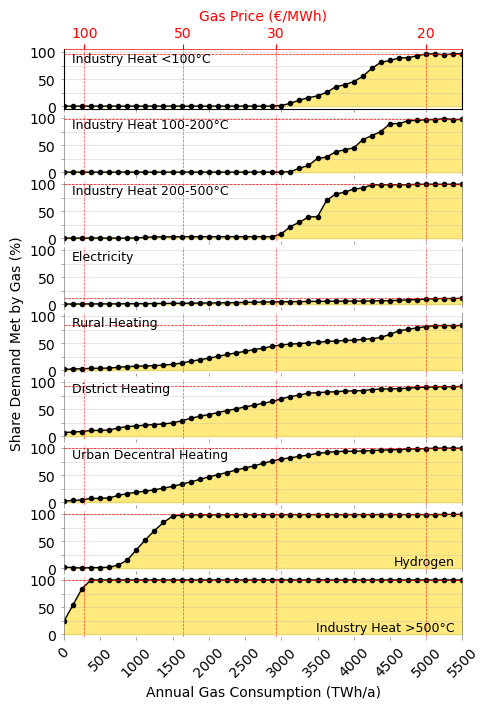

In [9]:
idx = pd.IndexSlice

fig, axes = plt.subplots(len(gas_techs_by_bus), 1, figsize=(5, 0.8 * len(gas_techs_by_bus)))

middle_ax_index = len(gas_techs_by_bus) // 2

# Get gas prices for interpolation
gas_prices = prices.loc['gas']

# Interpolate to find x-values where price is 20, 50, and 100
price_thresholds = [20, 30, 50, 100]
x_at_price = {}
for price_threshold in price_thresholds:
    # Find where price crosses the threshold
    x_at_price[price_threshold] = np.interp(price_threshold, gas_prices.values[::-1], gas_prices.index[::-1])

for i, (bc, techs) in enumerate(gas_techs_by_bus.items()):
    ax = axes[i] if len(gas_techs_by_bus) > 1 else axes
    
    # Get data for this bus carrier
    ss = eb.loc[idx[:, :, bc], :]
    
    # Calculate total inflow (sum of all positive values)
    total_inflow = ss[ss > 0].sum(axis=0)
    
    # Calculate gas tech contribution (sum of specified gas techs)
    gas_contribution = ss.loc[idx[:, techs, :], :].sum(axis=0)
    
    # Calculate percentage
    gas_percentage = (gas_contribution / total_inflow * 100).fillna(0)
    # Plot with thin line and small black markers
    x_values = prices.columns
    gas_percentage.index = x_values
    
    ax.plot(x_values, gas_percentage.values, linewidth=1, marker='o', markersize=3, color='black', markerfacecolor='black')
    
    # Add yellow-golden fill between
    ax.fill_between(x_values, np.zeros(len(x_values)), gas_percentage.values, color='gold', alpha=0.5)
    
    # Add red vertical lines at price thresholds
    for price_threshold in price_thresholds:
        ax.axvline(x_at_price[price_threshold], color='r', linestyle='--', linewidth=0.5, alpha=0.7)
    
    # Add bus carrier name as text
    if i >= len(gas_techs_by_bus) - 2:
        # Bottom two: place in bottom right
        ax.text(0.98, 0.05, nice_names[bc], transform=ax.transAxes, fontsize=9, 
                verticalalignment='bottom', horizontalalignment='right')
    else:
        # Others: place in top left
        ax.text(0.02, 0.95, nice_names[bc], transform=ax.transAxes, fontsize=9, 
                verticalalignment='top', horizontalalignment='left')
    
    # Set ylabel only for middle axis
    if i == middle_ax_index:
        ax.set_ylabel('Share Demand Met by Gas (%)')
    else:
        ax.set_ylabel('')
    
    ax.set_xlabel('')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Make spines grey to minimize weight
    for spine in ax.spines.values():
        spine.set_edgecolor('grey')
        spine.set_linewidth(0.5)

    ax.set_xticklabels([])
    ax.set_xlim(0, prices.columns[-1])
    
    # Set yticks at 0, 25, 50, 75, 100
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '', '50', '', '100'])
    ax.set_ylim(-5, 105)

    # Make tick marks more subtle
    ax.tick_params(axis='both', which='major', length=2, width=0.5, color='grey')

    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    if gas_percentage.values.max() < 100:
        ax.axhline(gas_percentage.values.max(), color='r', linestyle='--', linewidth=0.5)
    # Add twin x-axis for the first (top) subplot
    if i == 0:
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks([x_at_price[p] for p in price_thresholds])
        ax2.set_xticklabels([f'{p}' for p in price_thresholds])
        ax2.set_xlabel('Gas Price (€/MWh)', color='red')
        ax2.tick_params(axis='x', colors='red')
        ax2.spines['top'].set_edgecolor('red')
        ax2.spines['top'].set_linewidth(0.5)

axes[-1].set_xticks(range(0, 6000, 500))
axes[-1].set_xticklabels(range(0, 6000, 500), rotation=45)
axes[-1].set_xlabel('Annual Gas Consumption (TWh/a)')

plt.tight_layout(h_pad=-0.2)

plt.savefig('gas_phaseout_sector_by_sector.pdf')
plt.show()